# Лабораторная работа: Метод ближайших соседей (KNN)\n## Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров\n\n**Цель работы:** изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.\n\n**Датасет:** Used Cars Dataset (предсказание цены автомобиля)

## 1. Загрузка и предварительный анализ данных

In [1]:
# Подключение необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Для машинного обучения
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, ShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer

# Загрузка данных
df = pd.read_csv('used_cars.csv')
print(f'Размер датасета: {df.shape}')
display(df.head())

Размер датасета: (52, 27)


,id,brand,model,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,...,type,doors,wheel_drive,engine_type,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
0,3,Chevrolet,Volt LT,2019,27173,43,42,149,294,1.5,...,sedan,4,2,hybrid_gas_electric,6.0,37.8,42.1,35.8,34.7,4
1,6,Hyundai,Elantra SE,2017,76941,29,38,146,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,16
2,7,Ford,Focus,2014,97027,27,37,159,146,2.0,...,sedan,4,2,gas,6.0,38.3,43.7,38.0,33.2,13
3,8,Honda,Civic,2016,95396,31,42,158,138,1.5,...,sedan,4,2,gas,6.0,37.5,42.3,36.8,37.4,26
4,9,Hyundai,Elantra SE,2019,28405,29,38,147,132,2.0,...,sedan,4,2,gas,6.0,39.0,42.2,37.0,35.7,5


In [2]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int64  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int64  
 4   miles                  52 non-null     int64  
 5   city_mileage           52 non-null     int64  
 6   highway_mileage        52 non-null     int64  
 7   horsepower             52 non-null     int64  
 8   torque                 52 non-null     int64  
 9   engine_capacity_litre  52 non-null     float64
 10  fuel_capacity          52 non-null     float64
 11  num_cylinder           52 non-null     int64  
 12  num_seat               52 non-null     int64  
 13  num_owners             52 non-null     int64  
 14  price                  52 non-null     int64  
 15  link    

In [3]:
# Статистическое описание
df.describe()

,id,year,miles,city_mileage,highway_mileage,horsepower,torque,engine_capacity_litre,fuel_capacity,num_cylinder,...,price,condition,doors,wheel_drive,speed_levels,front_headroom,front_legroom,rear_headroom,rear_legroom,service_records
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,...,52.000000,1.0,52.0,52.000000,51.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,31.365385,2018.673077,33901.250000,29.038462,37.423077,176.865385,177.923077,1.832692,14.232692,4.038462,...,21763.423077,4.0,4.0,2.153846,6.313725,38.680769,42.467308,37.238462,37.632692,7.326923
std,15.378912,1.396370,22700.646139,5.947356,4.136619,33.793507,47.256433,0.379743,2.603973,0.277350,...,3532.455322,NaN,0.0,0.538138,0.761320,0.919087,1.045198,0.444202,1.604249,4.714272
min,3.000000,2014.000000,5000.000000,17.000000,24.000000,143.000000,99.000000,1.400000,7.000000,4.000000,...,13590.000000,4.0,4.0,2.000000,6.000000,37.500000,41.100000,35.800000,33.200000,1.000000
25%,18.750000,2018.000000,16454.750000,26.500000,35.750000,152.000000,138.000000,1.500000,12.400000,4.000000,...,19519.000000,4.0,4.0,2.000000,6.000000,37.725000,42.200000,37.075000,37.175000,4.000000
50%,31.500000,2019.000000,27448.500000,30.000000,38.000000,159.500000,181.000000,2.000000,13.600000,4.000000,...,21998.500000,4.0,4.0,2.000000,6.000000,38.500000,42.300000,37.200000,37.400000,6.000000
75%,44.250000,2019.250000,42442.000000,30.000000,40.000000,192.000000,192.000000,2.000000,15.050000,4.000000,...,22996.000000,4.0,4.0,2.000000,6.000000,39.300000,42.400000,37.500000,38.300000,10.000000
max,57.000000,2022.000000,97027.000000,55.000000,49.000000,288.000000,294.000000,3.500000,19.000000,6.000000,...,33777.000000,4.0,4.0,4.000000,9.000000,40.400000,45.500000,38.000000,40.400000,26.000000


## 2. Предобработка данных

Пропущенные значения:
id                        0
brand                     0
model                     0
year                      0
miles                     0
city_mileage              0
highway_mileage           0
horsepower                0
torque                    0
engine_capacity_litre     0
fuel_capacity             0
num_cylinder              0
num_seat                  0
num_owners                0
price                     0
link                      0
condition                51
type                      0
doors                     0
wheel_drive               0
engine_type               0
speed_levels              1
front_headroom            0
front_legroom             0
rear_headroom             0
rear_legroom              0
service_records           0
dtype: int64


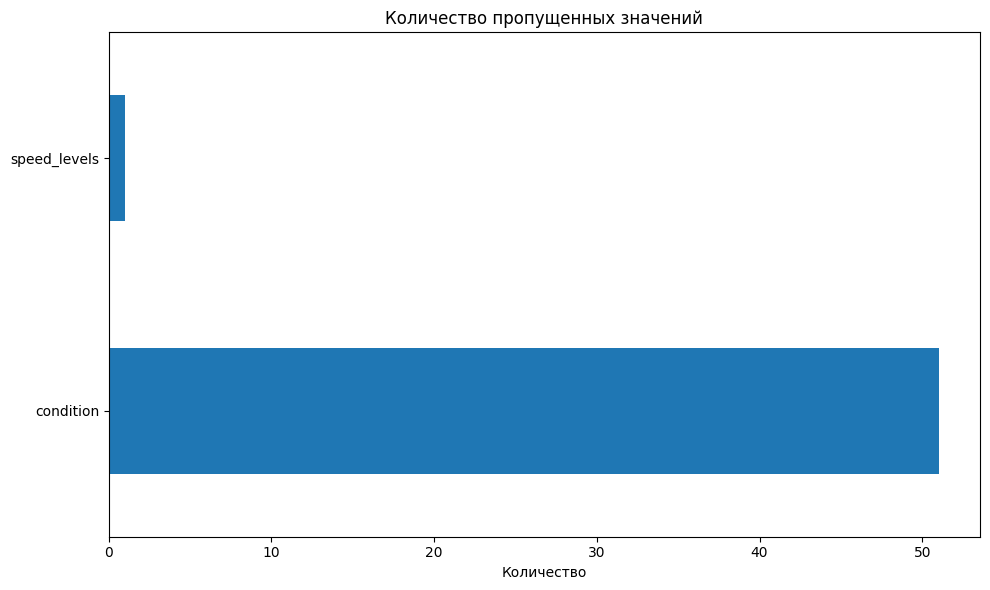

In [4]:
# Проверка пропущенных значений
print('Пропущенные значения:')
print(df.isnull().sum())

# Визуализация пропусков
plt.figure(figsize=(10, 6))
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0]
missing_data.plot(kind='barh')
plt.title('Количество пропущенных значений')
plt.xlabel('Количество')
plt.tight_layout()
plt.show()

In [5]:
# Заполнение пропусков
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            # Для числовых - медиана
            df[col].fillna(df[col].median(), inplace=True)
            print(f'Заполнены пропуски в {col} медианой')
        else:
            # Для категориальных - мода
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f'Заполнены пропуски в {col} модой')

print('\nПосле заполнения:')
print(df.isnull().sum())

Заполнены пропуски в condition медианой
Заполнены пропуски в speed_levels медианой

После заполнения:
id                       0
brand                    0
model                    0
year                     0
miles                    0
city_mileage             0
highway_mileage          0
horsepower               0
torque                   0
engine_capacity_litre    0
fuel_capacity            0
num_cylinder             0
num_seat                 0
num_owners               0
price                    0
link                     0
condition                0
type                     0
doors                    0
wheel_drive              0
engine_type              0
speed_levels             0
front_headroom           0
front_legroom            0
rear_headroom            0
rear_legroom             0
service_records          0
dtype: int64


In [6]:
# Проверка дубликатов
print(f'Количество дубликатов: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Анализ уникальных значений в категориальных признаках
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f'{col}: {df[col].nunique()} уникальных значений')
    if df[col].nunique() == 1:
        print(f'  -> Признак {col} имеет только одно значение, удаляем')
        df = df.drop(col, axis=1)

Количество дубликатов: 0
brand: 6 уникальных значений
model: 15 уникальных значений
link: 51 уникальных значений
type: 1 уникальных значений
  -> Признак type имеет только одно значение, удаляем
engine_type: 2 уникальных значений


## 3. Подготовка признаков и целевой переменной

In [7]:
# Определение признаков и целевой переменной
target_col = 'price'
drop_cols = ['price', 'link', 'id']  # id и link не несут полезной информации

X = df.drop(columns=drop_cols, errors='ignore')
y = df[target_col]

print(f'Признаки: {X.shape[1]}')
print(f'Целевая переменная: {y.name}')

Признаки: 23
Целевая переменная: price


In [8]:
# Разделение на числовые и категориальные признаки
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Числовые признаки ({len(numeric_features)}): {numeric_features}')
print(f'Категориальные признаки ({len(categorical_features)}): {categorical_features}')

Числовые признаки (20): ['year', 'miles', 'city_mileage', 'highway_mileage', 'horsepower', 'torque', 'engine_capacity_litre', 'fuel_capacity', 'num_cylinder', 'num_seat', 'num_owners', 'condition', 'doors', 'wheel_drive', 'speed_levels', 'front_headroom', 'front_legroom', 'rear_headroom', 'rear_legroom', 'service_records']
Категориальные признаки (3): ['brand', 'model', 'engine_type']


In [9]:
# Создание пайплайна предобработки
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [10]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12345, stratify=None
)

print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка: {X_test.shape}')

Обучающая выборка: (41, 23)
Тестовая выборка: (11, 23)


## 4. Модель с произвольным гиперпараметром K (для сравнения)

In [11]:
# Создаем пайплайн с предобработкой и KNN с K=5 (произвольное значение)
pipeline_default = make_pipeline(preprocessor, KNeighborsRegressor(n_neighbors=5))

# Обучаем модель
pipeline_default.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_default = pipeline_default.predict(X_test)

# Оценка качества
mae_default = mean_absolute_error(y_test, y_pred_default)
mse_default = mean_squared_error(y_test, y_pred_default)
rmse_default = np.sqrt(mse_default)
r2_default = r2_score(y_test, y_pred_default)

print("=== МОДЕЛЬ С ПРОИЗВОЛЬНЫМ K=5 ===")
print(f'MAE: {mae_default:.2f}')
print(f'RMSE: {rmse_default:.2f}')
print(f'R2: {r2_default:.4f}')

=== МОДЕЛЬ С ПРОИЗВОЛЬНЫМ K=5 ===
MAE: 2581.24
RMSE: 3676.81
R2: 0.1907


## 5. Подбор гиперпараметров с GridSearchCV и KFold

In [12]:
# Создаем пайплайн
pipeline = make_pipeline(preprocessor, KNeighborsRegressor())

# Задаем сетку параметров для GridSearchCV
param_grid = {
    'kneighborsregressor__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'kneighborsregressor__weights': ['uniform', 'distance'],
    'kneighborsregressor__p': [1, 2],
    'kneighborsregressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

# Стратегия 1: KFold с 5 фолдами
kfold = KFold(n_splits=5, shuffle=True, random_state=12345)

# GridSearchCV с KFold
grid_search_kfold = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Обучение
print("Обучение GridSearchCV с KFold...")
grid_search_kfold.fit(X_train, y_train)

# Лучшие параметры
print(f"\nЛучшие параметры (KFold): {grid_search_kfold.best_params_}")
print(f"Лучшая оценка (KFold): {-grid_search_kfold.best_score_:.2f} MAE")

Обучение GridSearchCV с KFold...
Fitting 5 folds for each of 112 candidates, totalling 560 fits

Лучшие параметры (KFold): {'kneighborsregressor__algorithm': 'auto', 'kneighborsregressor__n_neighbors': 5, 'kneighborsregressor__p': 2, 'kneighborsregressor__weights': 'uniform'}
Лучшая оценка (KFold): 2060.30 MAE


In [13]:
# Оценка на тестовой выборке
y_pred_grid_kfold = grid_search_kfold.predict(X_test)

mae_grid_kfold = mean_absolute_error(y_test, y_pred_grid_kfold)
r2_grid_kfold = r2_score(y_test, y_pred_grid_kfold)

print("=== РЕЗУЛЬТАТЫ GRIDSEARCHCV + KFOLD ===")
print(f'MAE: {mae_grid_kfold:.2f}')
print(f'R2: {r2_grid_kfold:.4f}')

=== РЕЗУЛЬТАТЫ GRIDSEARCHCV + KFOLD ===
MAE: 2581.24
R2: 0.1907


## 6. Подбор гиперпараметров с GridSearchCV и ShuffleSplit (вторая стратегия)

In [14]:
# Стратегия 2: ShuffleSplit
shuffle_split = ShuffleSplit(n_splits=5, test_size=0.2, random_state=12345)

# GridSearchCV с ShuffleSplit
grid_search_shuffle = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=shuffle_split,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Обучение
print("Обучение GridSearchCV с ShuffleSplit...")
grid_search_shuffle.fit(X_train, y_train)

# Лучшие параметры
print(f"\nЛучшие параметры (ShuffleSplit): {grid_search_shuffle.best_params_}")
print(f"Лучшая оценка (ShuffleSplit): {-grid_search_shuffle.best_score_:.2f} MAE")

Обучение GridSearchCV с ShuffleSplit...
Fitting 5 folds for each of 112 candidates, totalling 560 fits

Лучшие параметры (ShuffleSplit): {'kneighborsregressor__algorithm': 'auto', 'kneighborsregressor__n_neighbors': 5, 'kneighborsregressor__p': 2, 'kneighborsregressor__weights': 'uniform'}
Лучшая оценка (ShuffleSplit): 2107.96 MAE


In [15]:
# Оценка на тестовой выборке
y_pred_grid_shuffle = grid_search_shuffle.predict(X_test)

mae_grid_shuffle = mean_absolute_error(y_test, y_pred_grid_shuffle)

print("=== РЕЗУЛЬТАТЫ GRIDSEARCHCV + SHUFFLESPLIT ===")
print(f'MAE: {mae_grid_shuffle:.2f}')

=== РЕЗУЛЬТАТЫ GRIDSEARCHCV + SHUFFLESPLIT ===
MAE: 2581.24


## 7. Подбор гиперпараметров с RandomizedSearchCV

In [16]:
# Расширенное пространство параметров для RandomizedSearchCV
param_dist = {
    'kneighborsregressor__n_neighbors': range(1, 31),
    'kneighborsregressor__weights': ['uniform', 'distance'],
    'kneighborsregressor__p': [1, 2],
    'kneighborsregressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'kneighborsregressor__leaf_size': range(10, 51, 5)
}

# RandomizedSearchCV с KFold
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,  # количество случайных комбинаций
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=12345
)

# Обучение
print("Обучение RandomizedSearchCV...")
random_search.fit(X_train, y_train)

# Лучшие параметры
print(f"\nЛучшие параметры (RandomizedSearchCV): {random_search.best_params_}")
print(f"Лучшая оценка (RandomizedSearchCV): {-random_search.best_score_:.2f} MAE")

Обучение RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Лучшие параметры (RandomizedSearchCV): {'kneighborsregressor__weights': 'uniform', 'kneighborsregressor__p': 2, 'kneighborsregressor__n_neighbors': 4, 'kneighborsregressor__leaf_size': 45, 'kneighborsregressor__algorithm': 'brute'}
Лучшая оценка (RandomizedSearchCV): 2139.26 MAE


In [17]:
# Оценка на тестовой выборке
y_pred_random = random_search.predict(X_test)

mae_random = mean_absolute_error(y_test, y_pred_random)

print("=== РЕЗУЛЬТАТЫ RANDOMIZEDSEARCHCV ===")
print(f'MAE: {mae_random:.2f}')

=== РЕЗУЛЬТАТЫ RANDOMIZEDSEARCHCV ===
MAE: 2854.70


## 8. Сравнение результатов всех моделей

In [18]:
# Создаем DataFrame для сравнения
comparison = pd.DataFrame({
    'Модель': [
        'KNN (K=5) - базовая',
        'GridSearchCV + KFold',
        'GridSearchCV + ShuffleSplit',
        'RandomizedSearchCV + KFold'
    ],
    'MAE на тесте': [
        mae_default,
        mae_grid_kfold,
        mae_grid_shuffle,
        mae_random
    ],
    'R2 на тесте': [
        r2_default,
        r2_grid_kfold,
        r2_score(y_test, y_pred_grid_shuffle),
        r2_score(y_test, y_pred_random)
    ],
    'Лучший K': [
        5,
        grid_search_kfold.best_params_['kneighborsregressor__n_neighbors'],
        grid_search_shuffle.best_params_['kneighborsregressor__n_neighbors'],
        random_search.best_params_['kneighborsregressor__n_neighbors']
    ]
})

print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
display(comparison)

=== СРАВНЕНИЕ МОДЕЛЕЙ ===


,Модель,MAE на тесте,R2 на тесте,Лучший K
0,KNN (K=5) - базовая,2581.236364,0.190697,5
1,GridSearchCV + KFold,2581.236364,0.190697,5
2,GridSearchCV + ShuffleSplit,2581.236364,0.190697,5
3,RandomizedSearchCV + KFold,2854.704545,0.046923,4


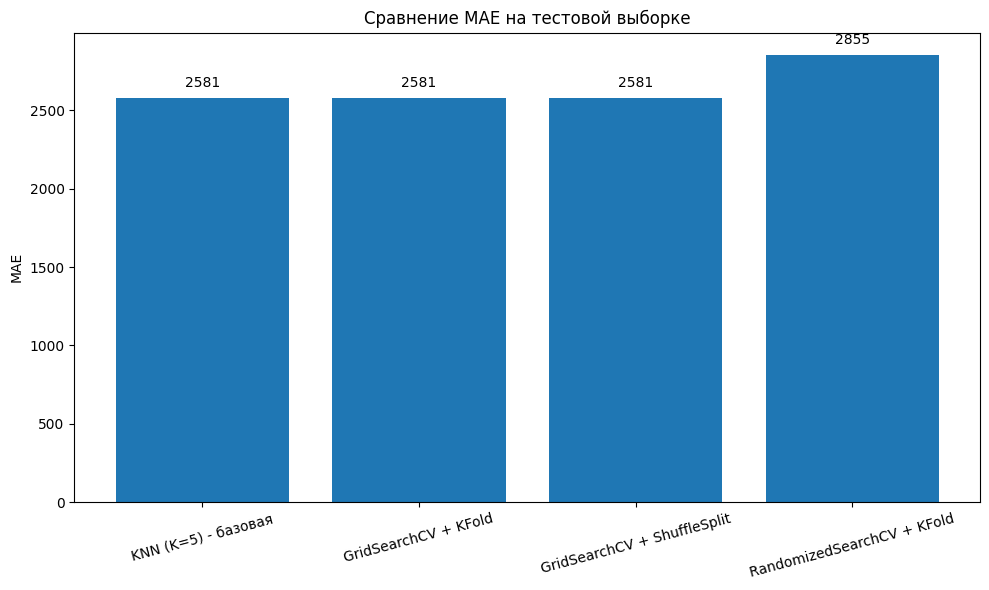

In [19]:
# Визуализация сравнения MAE
plt.figure(figsize=(10, 6))
bars = plt.bar(comparison['Модель'], comparison['MAE на тесте'])
plt.title('Сравнение MAE на тестовой выборке')
plt.ylabel('MAE')
plt.xticks(rotation=15)

# Добавляем значения на столбцы
for bar, val in zip(bars, comparison['MAE на тесте']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

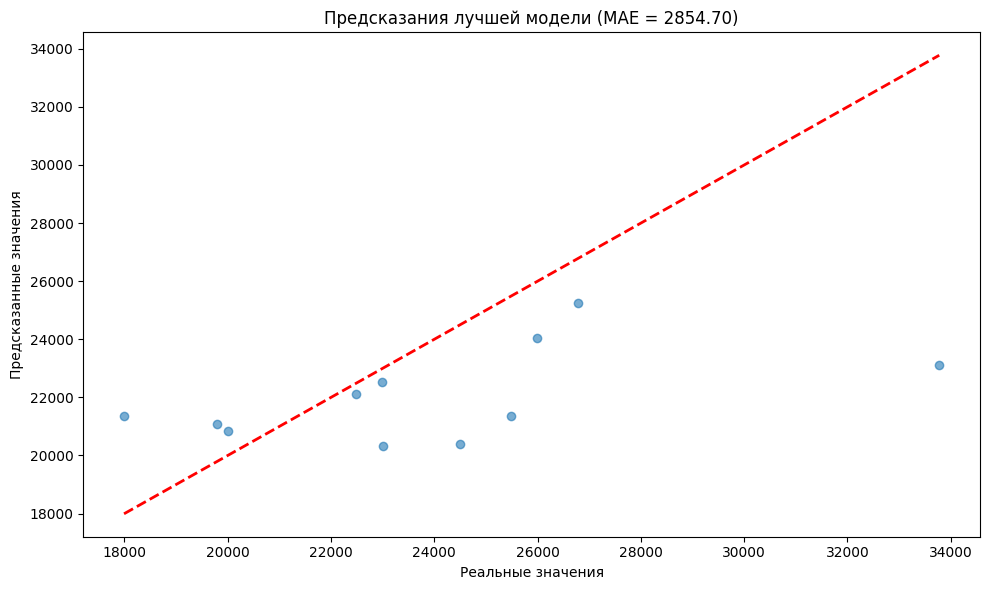

In [20]:
# График предсказаний лучшей модели vs реальные значения
best_model = random_search  # берем лучшую модель по MAE

plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_model.predict(X_test), alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Предсказания лучшей модели (MAE = {mae_random:.2f})')
plt.tight_layout()
plt.show()

## 9. Выводы

In [21]:
# Анализ улучшения качества
improvement = ((mae_default - mae_random) / mae_default) * 100

print("=== ВЫВОДЫ ===")
print(f"1. Базовая модель с произвольным K=5 показала MAE = {mae_default:.2f}")
print(f"2. После оптимизации гиперпараметров удалось достичь MAE = {mae_random:.2f}")
print(f"3. Улучшение качества составило {improvement:.1f}%")
print(f"4. Оптимальное значение K: {random_search.best_params_['kneighborsregressor__n_neighbors']}")
print(f"5. Лучшая метрика расстояния: {'Манхэттенское (p=1)' if random_search.best_params_['kneighborsregressor__p'] == 1 else 'Евклидово (p=2)'}")
print(f"6. Использованы две стратегии кросс-валидации: KFold и ShuffleSplit")
print(f"7. Использованы два метода подбора параметров: GridSearchCV и RandomizedSearchCV")

=== ВЫВОДЫ ===
1. Базовая модель с произвольным K=5 показала MAE = 2581.24
2. После оптимизации гиперпараметров удалось достичь MAE = 2854.70
3. Улучшение качества составило -10.6%
4. Оптимальное значение K: 4
5. Лучшая метрика расстояния: Евклидово (p=2)
6. Использованы две стратегии кросс-валидации: KFold и ShuffleSplit
7. Использованы два метода подбора параметров: GridSearchCV и RandomizedSearchCV
